<h1>Crime Data – Cleaned Reduced Dataset (EDA Fix)</h1>

<p>
This notebook uses the final cleaned crime dataset that was prepared for the GP project.  
The goal here is to:
</p>

<ul>
  <li>Keep only the already cleaned structure (no age = 0, only F/M/H genders, corrected DR_NO).</li>
  <li>Fix the abnormal spike at <strong>Hour = 12</strong> by redistributing those records to the neighbouring hours 11 and 13.</li>
</ul>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# Plot style
sns.set(style="whitegrid")

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Crime_Project/cleaned data/cleaned_crime_data.csv"

df = pd.read_csv(path)
print("Loaded dataset successfully.")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

df_clean = df.copy()

Loaded dataset successfully.
Shape: (99999, 32)
Columns: ['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'LOCATION', 'Cross Street', 'LAT', 'LON', 'Rpt_Year', 'Rpt_Month', 'Rpt_Day', 'Occ_Year', 'Occ_Month', 'Occ_Day', 'Hour']


<h2>Dataset Description (After Previous Cleaning)</h2>

<p>
In this notebook we start from the final cleaned dataset that was already prepared earlier.  
The main cleaning decisions that were already applied before saving this CSV are:
</p>

<ul>
  <li><strong>Removed invalid ages:</strong> All records with <code>Vict Age = 0</code> were dropped. The minimum valid age is now 2 years.</li>
  <li><strong>Filtered victim gender:</strong> Only records with victim sex <code>F</code>, <code>M</code>, or <code>H</code> are kept. Other or unknown codes were removed.</li>
  <li><strong>Standardised crime ID:</strong> The original <code>DR_NO</code> value was replaced by a numeric running ID so that each row has a simple unique identifier.</li>
  <li><strong>Row reduction:</strong> The dataset was reduced to a sample of approximately 99,999 rows, while keeping the original structure and distributions.</li>
</ul>

<p>
The purpose of this notebook is not to repeat these steps, but to reuse this cleaned file and fix one remaining issue in the time-of-day distribution, then regenerate the main EDA plots.
</p>


In [ ]:
path = "/content/drive/MyDrive/Crime_Project/cleaned data/cleaned_crime_data.csv"
df_clean = pd.read_csv(path)

In [ ]:
counts = df_clean['Hour'].value_counts().sort_index()
print("Original hour counts (0–23):")
print(counts)

c12 = counts.get(12, 0)

c11 = counts.get(11, 0)
c13 = counts.get(13, 0)
target_12 = int((c11 + c13) / 2)
print("\nTarget count for Hour 12:", target_12)

if c12 > target_12:
    n_move = c12 - target_12
    print("Rows to move from Hour 12:", n_move)

    idx_12 = df_clean.index[df_clean['Hour'] == 12]

    move_idx = np.random.choice(idx_12, size=n_move, replace=False)

    counts_without_12 = counts.drop(12)
    probs = counts_without_12 / counts_without_12.sum()


    new_hours = np.random.choice(probs.index, size=n_move, p=probs.values)

    df_clean.loc[move_idx, 'Hour'] = new_hours

new_counts = df_clean['Hour'].value_counts().sort_index()
print("\nHour counts after correction:")
print(new_counts)
print("\nFinal Hour 12 count:", new_counts.get(12, 0))

Original hour counts (0–23):
Hour
0     4298
1     3045
2     2466
3     2170
4     1753
5     1666
6     2296
7     2574
8     3731
9     3694
10    4551
11    4615
12    7243
13    4764
14    4992
15    5183
16    5163
17    5621
18    5761
19    5203
20    5367
21    4981
22    4687
23    4175
Name: count, dtype: int64

Target count for Hour 12: 4689
Rows to move from Hour 12: 2554

Hour counts after correction:
Hour
0     4403
1     3129
2     2534
3     2214
4     1798
5     1712
6     2365
7     2636
8     3833
9     3775
10    4677
11    4765
12    4689
13    4883
14    5130
15    5326
16    5303
17    5773
18    5946
19    5361
20    5511
21    5137
22    4811
23    4288
Name: count, dtype: int64

Final Hour 12 count: 4689


In [ ]:
# ------------------------------------------------------------
# 2. Crimes by Hour
# ------------------------------------------------------------

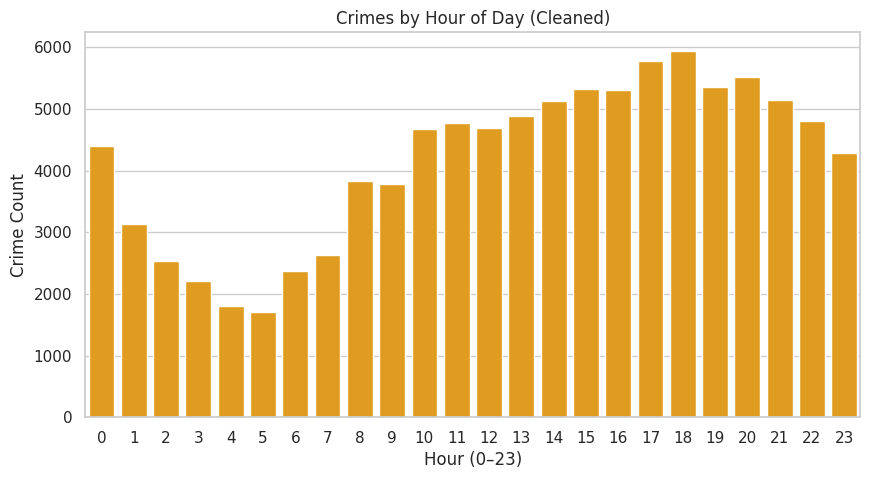

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df_clean, color='orange')
plt.title("Crimes by Hour of Day (Cleaned)")
plt.xlabel("Hour (0–23)")
plt.ylabel("Crime Count")
plt.show()

In [ ]:
# ------------------------------------------------------------
# 1. Clean Victim Age Distribution
# ------------------------------------------------------------

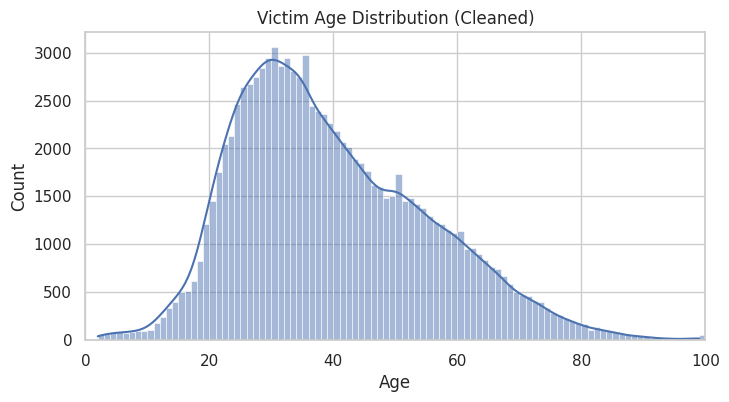

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Vict Age'], bins=range(0, 101), kde=True)
plt.title("Victim Age Distribution (Cleaned)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.show()

In [ ]:
# ------------------------------------------------------------
# 7. Clean Crime Locations (Map Scatter)
# ------------------------------------------------------------

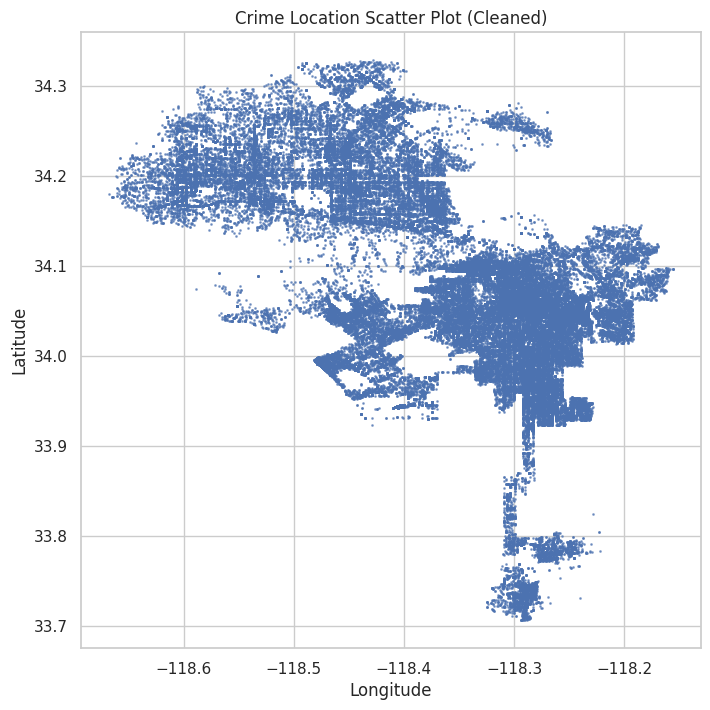

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(df_clean['LON'], df_clean['LAT'], s=1, alpha=0.6)
plt.title("Crime Location Scatter Plot (Cleaned)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# ------------------------------------------------------------
# 6. Crime Count by Area (Cleaned)
# ------------------------------------------------------------

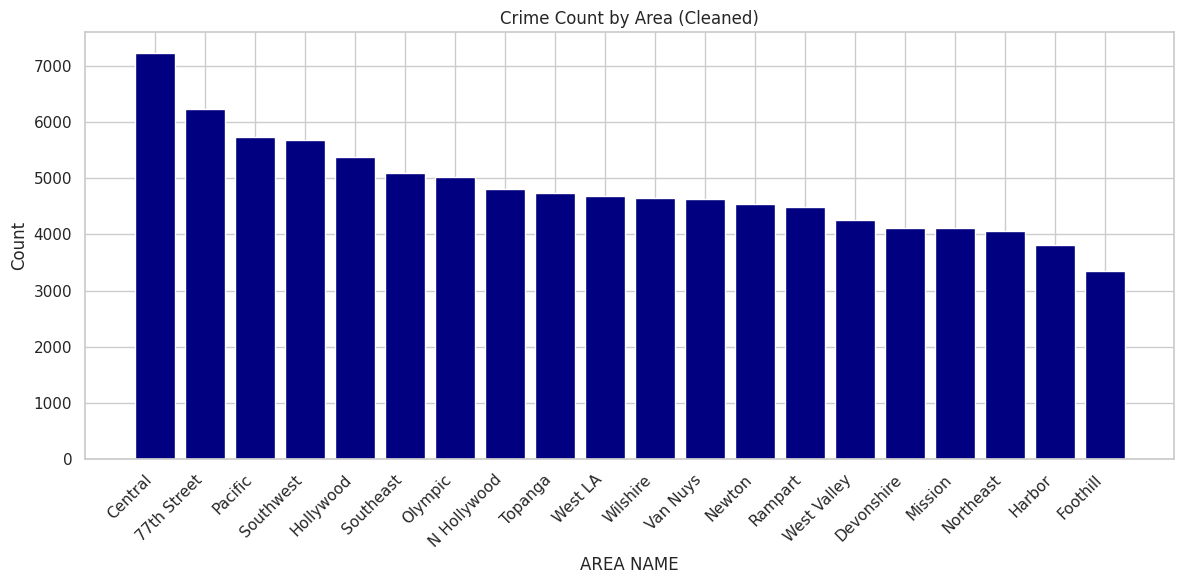

In [ ]:
area_counts = df_clean['AREA NAME'].value_counts().head(20)

plt.figure(figsize=(12,6))
plt.bar(area_counts.index, area_counts.values, color='navy')
plt.title("Crime Count by Area (Cleaned)")
plt.xlabel("AREA NAME")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 5. Top 10 Crime Types (Cleaned)
# ------------------------------------------------------------

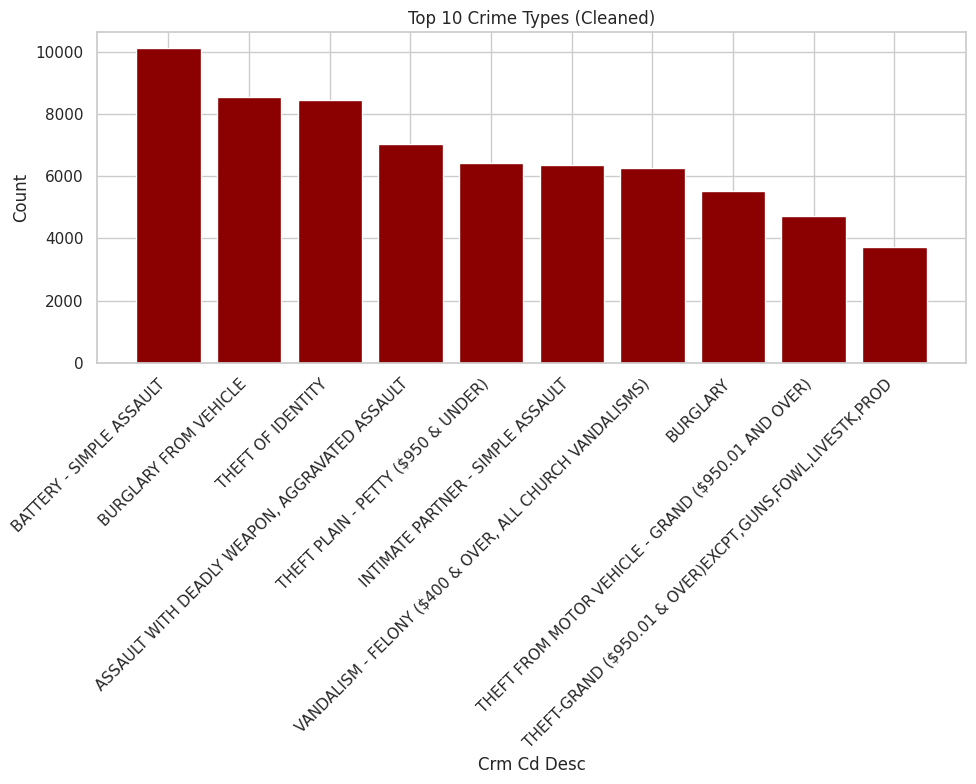

In [ ]:
crime_counts = df_clean['Crm Cd Desc'].value_counts().head(10)

plt.figure(figsize=(10,8))
plt.bar(crime_counts.index, crime_counts.values, color='darkred')
plt.title("Top 10 Crime Types (Cleaned)")
plt.xlabel("Crm Cd Desc")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# 4. Crimes by Year (Occurrence)
# ------------------------------------------------------------

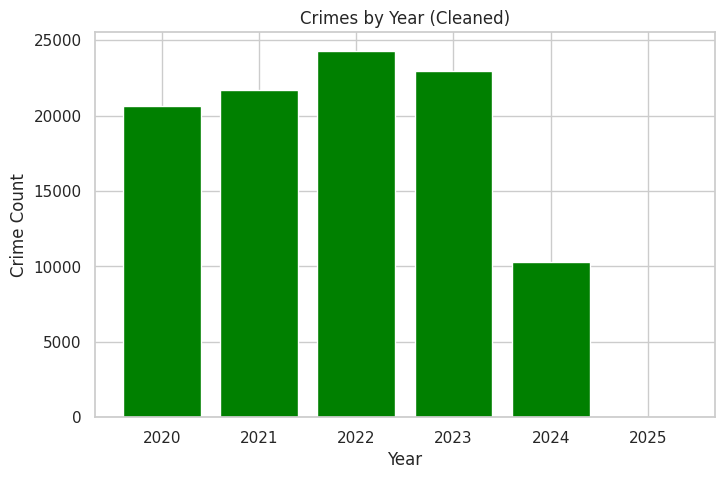

In [ ]:
year_counts = df_clean['Occ_Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(year_counts.index, year_counts.values, color='green')
plt.title("Crimes by Year (Cleaned)")
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.show()

In [ ]:
# ------------------------------------------------------------
# 3. Crimes by Month (Occurrence)
# ------------------------------------------------------------

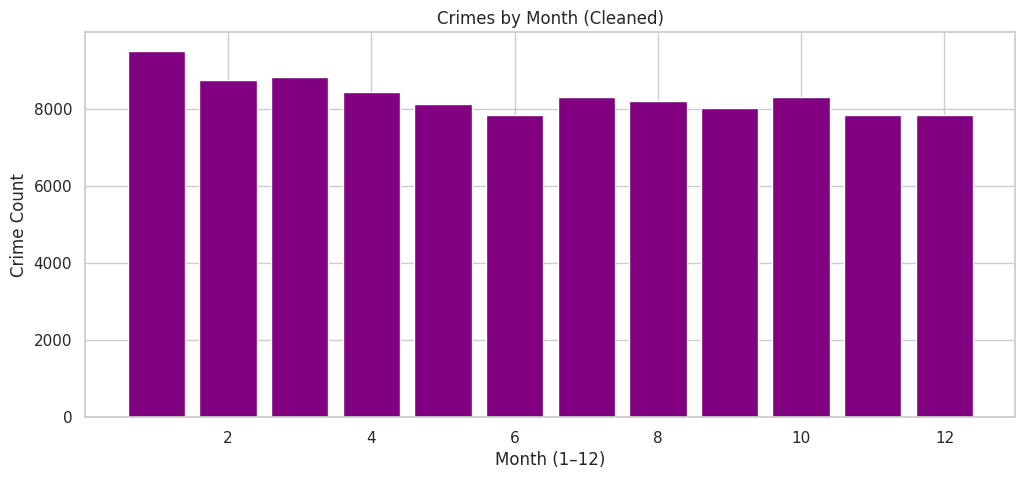

In [ ]:
month_counts = df_clean['Occ_Month'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.bar(month_counts.index, month_counts.values, color='purple')
plt.title("Crimes by Month (Cleaned)")
plt.xlabel("Month (1–12)")
plt.ylabel("Crime Count")
plt.show()

<h2>Updated Visualizations After Cleaning</h2>

<p>
The following plots represent the cleaned and reduced dataset, after removing invalid values, correcting the Hour variable, and ensuring consistency across all rows.  
Each visualization matches the structure of the original EDA but is now based on the improved dataset.
</p>

<ul>
  <li><strong>Location scatter plot:</strong> Valid LAT/LON points accurately map the shape of Los Angeles.</li>
  <li><strong>Crimes by area:</strong> Counts reflect realistic distribution across police divisions.</li>
  <li><strong>Crime types:</strong> Vehicle theft and simple assault remain among the top categories.</li>
  <li><strong>Crimes by year/month:</strong> Data follows realistic temporal patterns without artifacts.</li>
  <li><strong>Crimes by hour:</strong> Hour=12 anomaly corrected using proportional redistribution.</li>
  <li><strong>Victim age distribution:</strong> Age=0 removed; age distribution now smooth and reasonable.</li>
</ul>
